In [346]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [347]:
df_tickets = pd.read_csv('tickets.csv')
df_tickets.head(10)

,depart_date,origin,destination,gate,trip_class,value,duration,distance,market,currency,rate
0,2026-06-01,MOW,LED,Kupi.com,0,294,90,624,ru,cny,11.500647
1,2026-06-03,MOW,LED,Kupi.com,0,294,90,598,ru,cny,11.500647
2,2026-06-06,MOW,LED,Kupi.com,0,337,90,624,ru,cny,11.500647
3,2026-06-04,MOW,LED,Т-Банк,0,337,90,624,ru,cny,11.500647
4,2026-06-02,MOW,LED,Kupi.com,0,337,90,598,ru,cny,11.500647
5,2026-06-24,MOW,LED,Т-Банк,0,339,90,598,ru,cny,11.500647
6,2026-06-23,MOW,LED,Т-Путешествия,0,339,90,624,ru,cny,11.500647
7,2026-06-20,MOW,LED,OneTwoTrip Railways,0,345,231,634,ru,cny,11.500647
8,2026-06-08,MOW,LED,OneTwoTrip Railways,0,345,241,634,ru,cny,11.500647
9,2026-06-13,MOW,LED,OneTwoTrip Railways,0,345,231,634,ru,cny,11.500647


Добаим столбец который показывает цену в рублях чтобы дальше было удобнее анализировать

In [348]:
df_tickets['value_rub']=df_tickets['value']*df_tickets['rate'].round()
df_tickets.head()

,depart_date,origin,destination,gate,trip_class,value,duration,distance,market,currency,rate,value_rub
0,2026-06-01,MOW,LED,Kupi.com,0,294,90,624,ru,cny,11.500647,3528.0
1,2026-06-03,MOW,LED,Kupi.com,0,294,90,598,ru,cny,11.500647,3528.0
2,2026-06-06,MOW,LED,Kupi.com,0,337,90,624,ru,cny,11.500647,4044.0
3,2026-06-04,MOW,LED,Т-Банк,0,337,90,624,ru,cny,11.500647,4044.0
4,2026-06-02,MOW,LED,Kupi.com,0,337,90,598,ru,cny,11.500647,4044.0


In [349]:
df_tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248645 entries, 0 to 248644
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   depart_date  248645 non-null  object 
 1   origin       248645 non-null  object 
 2   destination  248645 non-null  object 
 3   gate         222158 non-null  object 
 4   trip_class   248645 non-null  int64  
 5   value        248645 non-null  int64  
 6   duration     248645 non-null  int64  
 7   distance     248645 non-null  int64  
 8   market       248645 non-null  object 
 9   currency     248645 non-null  object 
 10  rate         248645 non-null  float64
 11  value_rub    248645 non-null  float64
dtypes: float64(2), int64(4), object(6)
memory usage: 22.8+ MB


Видим Null только в поле gate - источнике билетов

In [350]:
df_tickets[df_tickets['gate'].isna()]

,depart_date,origin,destination,gate,trip_class,value,duration,distance,market,currency,rate,value_rub
42520,2026-06-23,MOW,RTW,NaN,0,655,0,0,ru,cny,11.500647,7860.0
42521,2026-06-14,MOW,RTW,NaN,0,672,0,0,ru,cny,11.500647,8064.0
42549,2026-06-23,MOW,RTW,NaN,0,96,0,0,ru,usd,78.551719,7584.0
42550,2026-06-14,MOW,RTW,NaN,0,98,0,0,ru,usd,78.551719,7742.0
42578,2026-06-23,MOW,RTW,NaN,0,7536,0,0,ru,rub,1.000000,7536.0
...,...,...,...,...,...,...,...,...,...,...,...,...
248516,2026-06-07,MOW,PWE,NaN,0,710,0,0,nl,usd,78.551719,56090.0
248520,2026-06-21,MOW,PWE,NaN,0,50762,0,0,nl,rub,1.000000,50762.0
248524,2026-06-07,MOW,PWE,NaN,0,55791,0,0,nl,rub,1.000000,55791.0
248530,2026-06-21,MOW,PWE,NaN,0,554,0,0,nl,eur,91.861107,50968.0


Эти строки умеют пропуск только в gate и их большое количество(более 10%) поэтому оставим их для дальнейшего анализа других взаимосвязей, пропуски заполнять никак не будем


In [351]:
df_tickets.describe()

,trip_class,value,duration,distance,rate,value_rub
count,248645.0,2.486450e+05,248645.000000,248645.000000,248645.000000,248645.000000
mean,0.0,2.631085e+04,368.469666,2007.273217,40.337193,12300.907314
std,0.0,2.103752e+05,569.227099,1740.907332,39.141596,6748.863734
min,0.0,3.700000e+01,0.000000,0.000000,0.006425,0.000000
25%,0.0,1.490000e+02,105.000000,818.000000,1.000000,7544.000000
50%,0.0,6.120000e+02,185.000000,1440.000000,11.500647,11408.000000
75%,0.0,6.476000e+03,395.000000,2874.000000,78.551719,16728.000000
max,0.0,9.578216e+06,3790.000000,6795.000000,91.861107,102357.000000


In [352]:
df_tickets.duplicated().sum()

np.int64(0)

В датасете нет полных дубликатов 

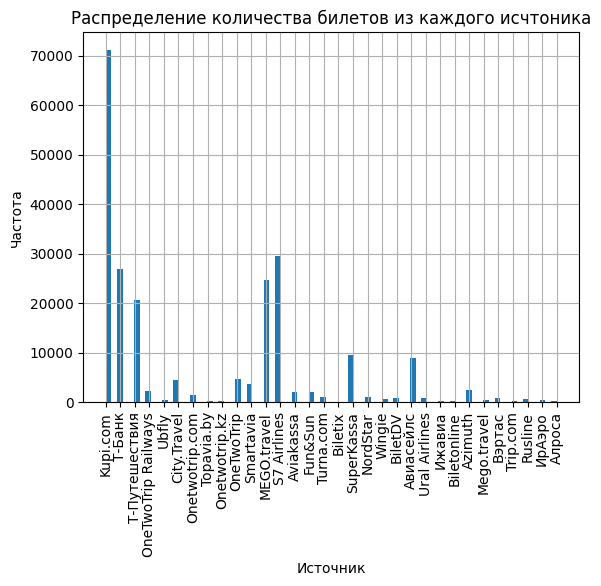

In [353]:

df_tickets['gate'].hist(bins=80)

plt.xlabel("Источник")
plt.ylabel("Частота")
plt.title("Распределение количества билетов из каждого исчтоника")
plt.xticks(rotation=90)
plt.show()


Видим очень неравномерное распределние по источнику билета

In [354]:
df_tickets['gate'].value_counts()

gate
Kupi.com               71178
S7 Airlines            29426
Т-Банк                 26940
MEGO.travel            24745
Т-Путешествия          20579
SuperKassa              9544
Авиасейлс               8808
OneTwoTrip              4719
City.Travel             4391
Smartavia               3597
Azimuth                 2398
OneTwoTrip Railways     2162
Fun&Sun                 2087
Aviakassa               1923
Onetwotrip.com          1423
NordStar                 992
Turna.com                955
Вэртас                   872
BiletDV                  867
Ural Airlines            847
Wingie                   689
Rusline                  644
Ubfly                    427
ИрАэро                   327
Mego.travel              327
Onetwotrip.kz            290
Алроса                   218
Ижавиа                   218
Trip.com                 215
Biletonline              190
Topavia.by               150
Biletix                   10
Name: count, dtype: int64

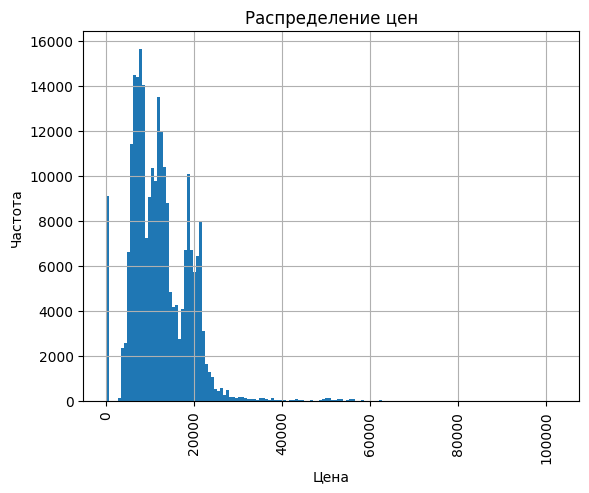

In [355]:
df_tickets['value_rub'].hist(bins=150)

plt.xlabel("Цена")
plt.ylabel("Частота")
plt.title("Распределение цен")
plt.xticks(rotation=90)
plt.show()


In [356]:
df_tickets['value_rub'].describe()

count    248645.000000
mean      12300.907314
std        6748.863734
min           0.000000
25%        7544.000000
50%       11408.000000
75%       16728.000000
max      102357.000000
Name: value_rub, dtype: float64

Максимум выглядит адекватным, но вот нулевых цен быть не должно по идее. На графике видно что их более 9к. Уберем эти строки из датасета как невалидные. 

In [357]:
df_prepared = df_tickets[df_tickets['value_rub']!=0]
(df_prepared['value_rub']<2000).sum()


np.int64(0)

In [358]:
df_prepared['destination'].value_counts()

destination
LED    3150
NAL    3150
AER    3150
UUD    3150
MQF    3150
       ... 
IWA     105
KNY     105
PYJ     105
ODO     105
IAA     105
Name: count, Length: 97, dtype: int64

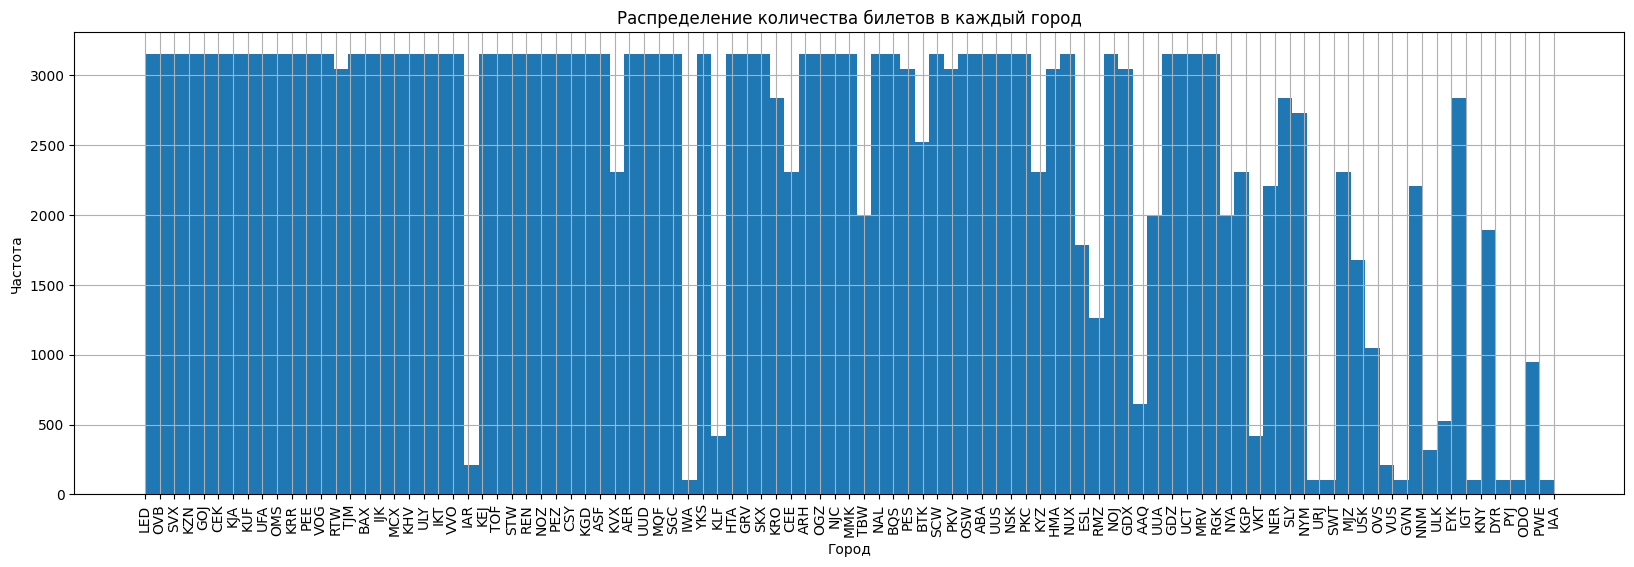

In [359]:

plt.figure(figsize=(20, 6))
df_prepared['destination'].hist(bins=97)

plt.xlabel("Город")
plt.ylabel("Частота")
plt.title("Распределение количества билетов в каждый город")
plt.xticks(rotation=90)

plt.show()


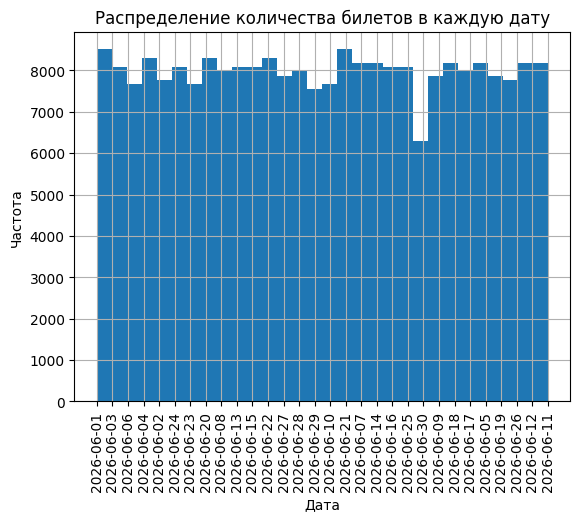

In [360]:
df_prepared['depart_date'].hist(bins=30)

plt.xlabel("Дата")
plt.ylabel("Частота")
plt.title("Распределение количества билетов в каждую дату")
plt.xticks(rotation=90)
plt.show()


Видим достаточно равномерное распределение не считая 30 июня, может быть связано с тем что это самая дальняя дата и пока не все билеты опубликовали


Заранее уберем нереалистичное время полета - 0 минут и более 9.5 часов

In [361]:
df_prepared= df_prepared[df_prepared['duration']<570]
df_prepared= df_prepared[df_prepared['duration']!=0]

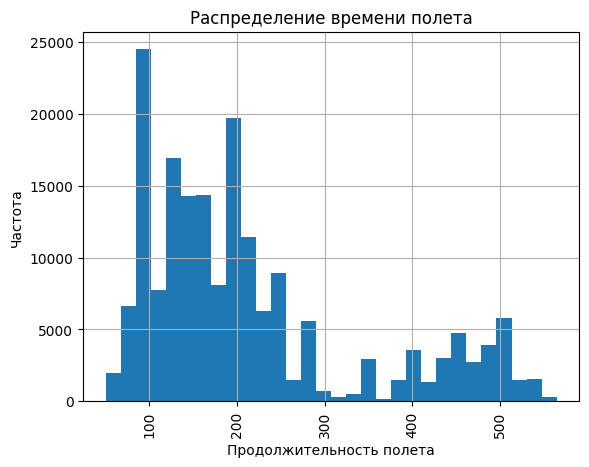

In [362]:
df_prepared['duration'].hist(bins=30)

plt.xlabel("Продолжительность полета")
plt.ylabel("Частота")
plt.title("Распределение времени полета")
plt.xticks(rotation=90)
plt.show()

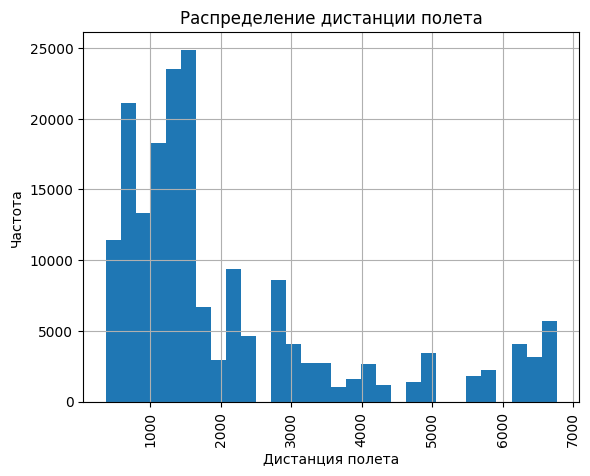

In [363]:
df_prepared['distance'].hist(bins=30)

plt.xlabel("Дистанция полета")
plt.ylabel("Частота")
plt.title("Распределение дистанции полета")
plt.xticks(rotation=90)
plt.show()


In [364]:
df_prepared[df_prepared['distance']<100].sum()

depart_date      0
origin           0
destination      0
gate             0
trip_class       0
value            0
duration         0
distance         0
market           0
currency         0
rate           0.0
value_rub      0.0
dtype: object

В дистанции полета также не выявлено выбросов

Дальше проверим гипотезу, что на русском рынке покупать билеты для прямых перелетов внутри России немного дешевле чем покупать их на иостранном рынке
Рынок хранится в поле "market"

In [365]:
df_grouped = df_prepared.groupby(['destination', 'market', 'depart_date'])['value_rub'].mean().reset_index()


In [366]:
idx_min = df_grouped.groupby(['destination','depart_date'])['value_rub'].idxmin()
cheapest = df_grouped.loc[idx_min]
cheapest['market'].value_counts()

market
tj    1656
ru      45
by      15
kz      13
us       8
il       6
uz       4
az       4
am       2
fr       1
Name: count, dtype: int64

Группируем по уникальнм комбинациям дня и назначения и сравниваем среднюю цену на это маркете

In [367]:
ru_sum_value = df_grouped['value_rub'][df_grouped['market']=='ru'].sum() 
tj_sum_value = df_grouped['value_rub'][df_grouped['market']=='tj'].sum() 

print(ru_sum_value)
print(tj_sum_value)

print(ru_sum_value-tj_sum_value)

19841154.25
19772065.0
69089.25


Самым дешевым рынком с огромным отрывом по количеству дешевых направлений оказалося Таджикистан. Однако суммарная экономия получается лишь 70к  рублей, что для более чем 1.7к билетов является не значимым

Вероятно это разница появилась из-за перевода между валютами

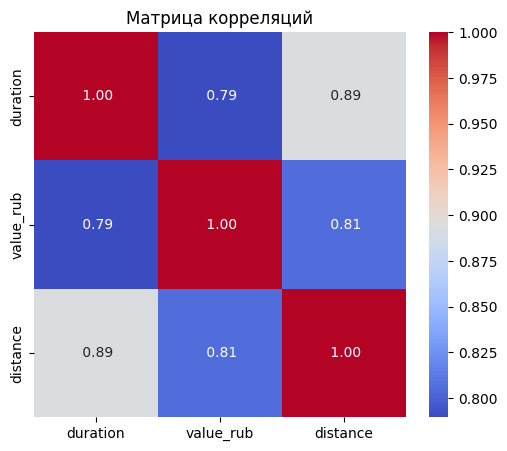

In [368]:
corr = df_prepared[['duration','value_rub','distance']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=" .2f", cmap="coolwarm")
plt.title("Матрица корреляций")
plt.show()

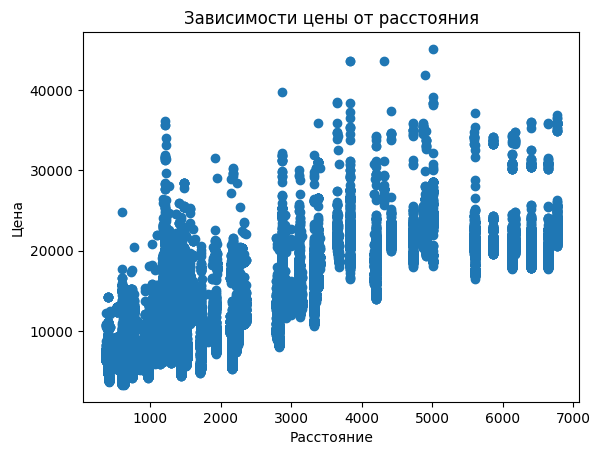

In [369]:
plt.scatter(df_prepared['distance'], df_prepared['value_rub'])

plt.xlabel("Расстояние")
plt.ylabel("Цена")
plt.title("Зависимости цены от расстояния")

plt.show()

In [370]:
print(df_prepared[df_prepared['gate']=='Т-Банк'].count()[0])
print(df_prepared[df_prepared['gate']=='Т-Путешествия'].count()[0])

24497
19412


/var/folders/nh/jsrfmj8x2rnf4qjv8_g89b5m0000gq/T/ipykernel_16047/66999833.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df_prepared[df_prepared['gate']=='Т-Банк'].count()[0])
/var/folders/nh/jsrfmj8x2rnf4qjv8_g89b5m0000gq/T/ipykernel_16047/66999833.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(df_prepared[df_prepared['gate']=='Т-Путешествия'].count()[0])


Видим разное количество предложений 

In [371]:
df_grouped_T = df_prepared.groupby(['destination', 'gate', 'depart_date'])['value_rub'].mean().reset_index()

In [372]:
df_grouped_T = df_grouped_T[(df_grouped_T['gate']=='Т-Банк') |  (df_grouped_T['gate']=='Т-Путешествия')]
df_grouped_T


,destination,gate,depart_date,value_rub
91,AER,Т-Банк,2026-06-01,10853.184783
92,AER,Т-Банк,2026-06-16,13296.677083
93,AER,Т-Банк,2026-06-19,12765.857143
94,AER,Т-Банк,2026-06-20,13298.697917
95,AER,Т-Банк,2026-06-25,12808.560000
...,...,...,...,...
2221,VVO,Т-Путешествия,2026-06-01,19306.600000
2222,VVO,Т-Путешествия,2026-06-16,19450.514286
2223,VVO,Т-Путешествия,2026-06-18,19196.971429
2224,VVO,Т-Путешествия,2026-06-26,19114.371429


In [373]:


dest_1 = set(df_grouped_T[df_grouped_T['gate'] == 'Т-Банк']['destination'])
dest_2 = set(df_grouped_T[df_grouped_T['gate'] == 'Т-Путешествия']['destination'])

In [374]:
only_in_1 = dest_1 - dest_2
only_in_2 = dest_2 - dest_1

in_every = dest_1 & dest_2

print(only_in_1, only_in_2)
print(in_every)

{'GOJ', 'KZN', 'USK', 'YKS', 'PES', 'SGC'} {'IKT', 'NUX', 'NYM', 'TJM'}
{'UFA', 'OSW', 'OMS', 'MQF', 'RTW', 'KGD', 'OVB', 'GRV', 'VOG', 'BAX', 'LED', 'VVO', 'REN', 'UUS', 'MMK', 'KGP', 'NOJ', 'KVX', 'KRR', 'KRO', 'AER', 'UCT', 'MRV', 'SVX', 'ASF', 'NAL', 'HMA', 'CSY', 'ESL', 'PEE', 'HTA', 'KHV', 'OGZ', 'PKV', 'ULY', 'GDZ', 'STW', 'BQS', 'TBW', 'KJA', 'IGT', 'SCW', 'CEK', 'MCX'}


Можем увидеть что различаются даже направления, что достаточно странно

In [375]:
df_grouped_T = df_grouped_T[df_grouped_T['destination'].isin(in_every)]

In [376]:
bank_sum_value = df_grouped_T['value_rub'][df_grouped_T['gate']=='Т-Банк'].sum() 
travel_sum_value = df_grouped_T['value_rub'][df_grouped_T['gate']=='Т-Путешествия'].sum() 

print(bank_sum_value)
print(travel_sum_value)

print(bank_sum_value-travel_sum_value)

2676655.1511526825
1971818.2279835697
704836.9231691128


Получилось, что покупать билеты через Т-путешествия гораздо выгоднее